# 02 · Time-Series Foundations — Stationarity, Decomposition, ACF/PACF

## Part 2 — Time-Series Foundations

Cross-sectional EDA (Part 1) asks *how are the columns distributed and related?* A time series
adds an axis that changes everything: **order matters**. Observations are indexed by time, and
the value today is correlated with the value yesterday. That dependence is the signal — and the
thing that breaks ordinary statistics (a t-test assumes i.i.d. rows; returns are not i.i.d.).

This notebook builds the vocabulary every forecasting model relies on:

| # | concept | the question it answers |
|---|---|---|
| 1 | **Index hygiene** | is the time axis regular, gapless, and correctly typed? |
| 2 | **Visual diagnosis** | what does trend / changing variance look like? |
| 3 | **Components** | trend + seasonality + cycle + noise — additive or multiplicative? |
| 4 | **Decomposition** | classical vs **STL**, and how to read the panels |
| 5 | **Stationarity** | does the distribution drift over time? (**ADF × KPSS**) |
| 6 | **ACF / PACF** | how far back does memory reach? which model order? |
| 7 | **Volatility clustering** | the variance has its own memory (ARCH) |
| 8 | **Differencing** | how to *make* a series stationary — without over-doing it |

Primary series: **S&P 500** (Shiller monthly). Decomposition teaching aid: **Mauna Loa CO₂**
(real atmospheric data with a textbook seasonal cycle), because an equity index has trend but
almost no calendar seasonality — itself a finding we confirm in §4.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import ts
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.datasets import co2

shiller = data.clean_shiller()
price = shiller["SP500"]
logp  = np.log(price)
ret   = shiller["return"].dropna()
logret = shiller["log_return"].dropna()
# Mauna Loa CO2 -> monthly, for a series with UNMISTAKABLE trend + seasonality.
co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
print("shiller:", price.index.min().date(), "->", price.index.max().date(), "| co2:", co2m.index.min().date(), "->", co2m.index.max().date())


setup ok | numpy 2.1.3 | pandas 2.3.3


shiller: 1871-01-01 -> 2026-05-01 | co2: 1958-03-01 -> 2001-12-01


### 1. Index hygiene — the foundation everything else stands on

Before any model, the time axis must be **typed as datetime**, **sorted**, **gapless**, and
carry an explicit **frequency**. A silent gap or a string index will not error — it will quietly
corrupt every lag, rolling window, and seasonal period downstream.

Checklist:
- `DatetimeIndex` (not strings), monotonic increasing, no duplicate timestamps
- a declared frequency (`MS` = month-start here) so `.shift`, `.diff`, `.resample` are meaningful
- a deliberate choice for any gaps: forward-fill (carry last), interpolate, or leave NaN

In [2]:
idx = price.index
print("dtype          :", idx.dtype)
print("monotonic inc. :", idx.is_monotonic_increasing)
print("duplicates     :", int(idx.duplicated().sum()))
print("declared freq  :", idx.freq)
# A gapless monthly grid should have exactly this many periods:
expected = pd.date_range(idx.min(), idx.max(), freq="MS")
print("len(series)    :", len(idx), "| expected on a gapless MS grid:", len(expected), "| missing slots:", len(expected.difference(idx)))

dtype          : datetime64[ns]
monotonic inc. : True
duplicates     : 0
declared freq  : <MonthBegin>
len(series)    : 1865 | expected on a gapless MS grid: 1865 | missing slots: 0


**Resampling** changes the frequency. *Down*-sampling aggregates (monthly → annual, using a
reducer like mean/last); *up*-sampling creates new slots that must be filled. Note how the
annual return is **not** the sum of monthly returns — returns compound, they don't add.

In [3]:
annual_last = price.resample("YE").last()          # downsample: year-end price
annual_ret  = annual_last.pct_change()
print("Down-sampled to annual (year-end price), last 3 years:")
print(annual_last.tail(3).round(1).to_string())
print("\n2020 annual return from year-end prices: %.1f%%" % (100*annual_ret.loc["2020"].iloc[0]))
print("Sum of 2020 monthly returns (WRONG way):     %.1f%%" % (100*ret.loc["2020"].sum()))
print("Compounded 2020 monthly returns (right way): %.1f%%" % (100*((1+ret.loc["2020"]).prod()-1)))

Down-sampled to annual (year-end price), last 3 years:
Date
2024-12-31    6010.9
2025-12-31    6853.0
2026-12-31    7412.6
Freq: YE-DEC

2020 annual return from year-end prices: 16.3%
Sum of 2020 monthly returns (WRONG way):     18.1%
Compounded 2020 monthly returns (right way): 16.3%


### 2. Visual diagnosis — always look first

Two plots answer most questions before a single test:

- **Level + rolling mean** → is there a *trend* (a drifting mean)?
- **Rolling std** → is the *variance* constant, or does it cluster into calm and turbulent regimes?

A flat rolling mean and a flat rolling band ≈ stationary. Drift or a breathing band ≈ not.

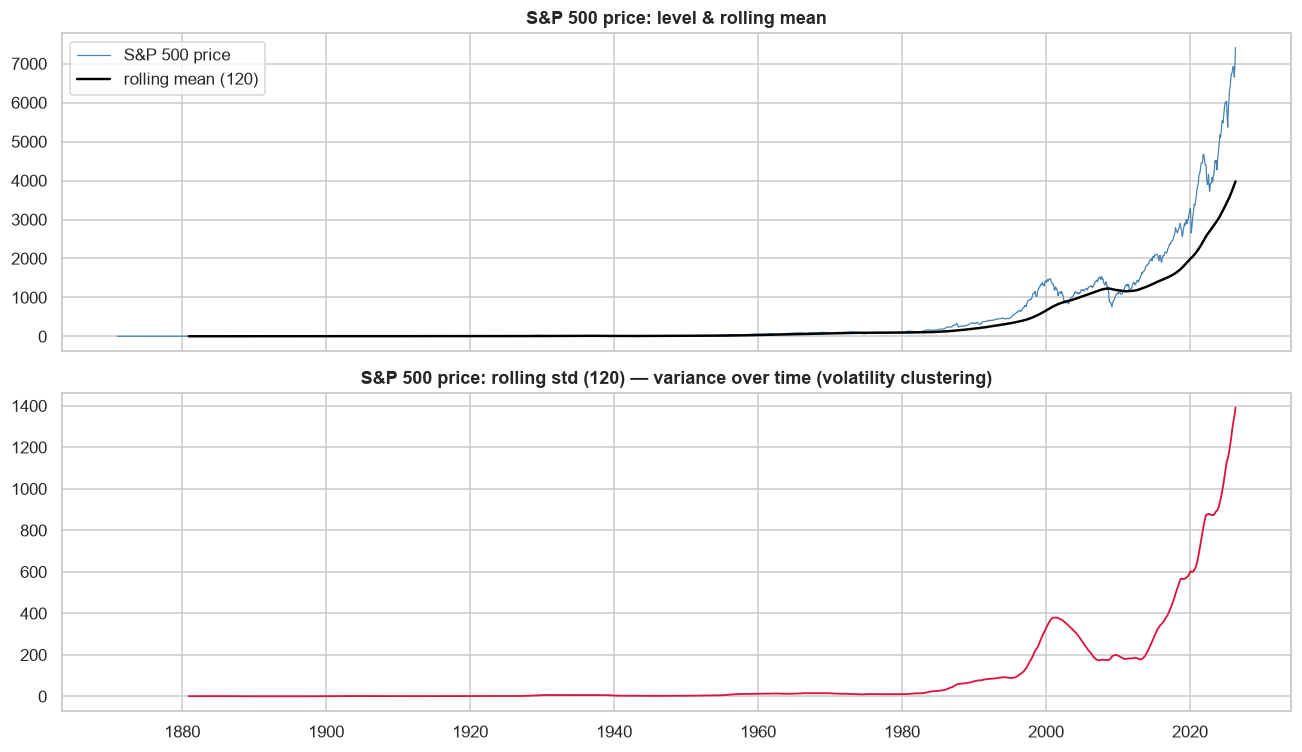

In [4]:
fig = ts.rolling_plot(price, window=120, name="S&P 500 price", fname="p2_rolling_price.png")
plt.show()

The mean marches upward (strong **trend**) and the band widens (variance grows with the
price level) → emphatically non-stationary, and *multiplicative* in character. The fix for the
growing variance is a **log transform**: on a log scale the exponential trend becomes a straight
line and percentage moves get equal vertical space.

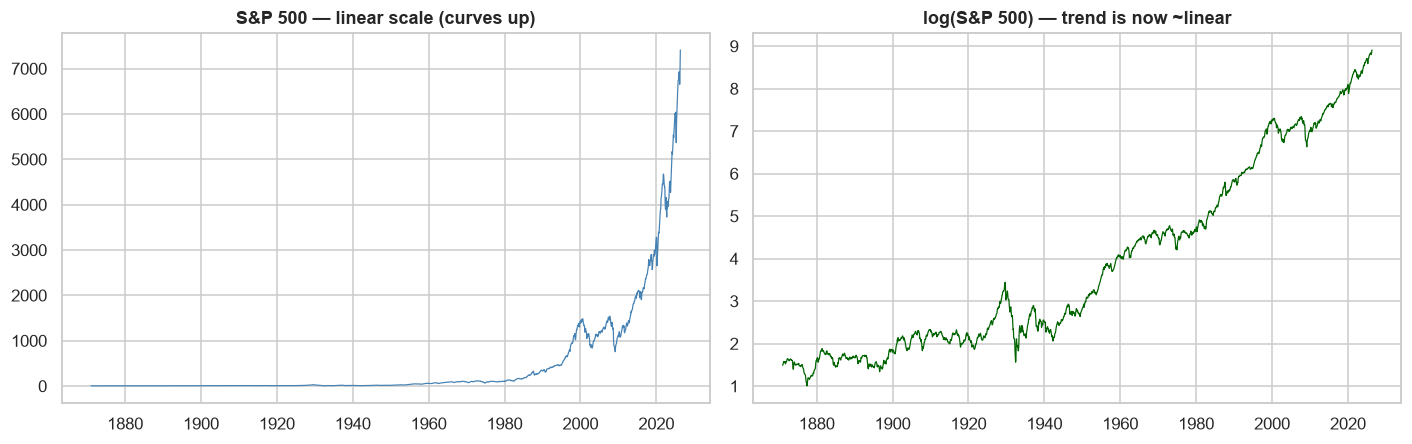

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(price.index, price, color="steelblue", lw=0.8); ax[0].set_title("S&P 500 — linear scale (curves up)")
ax[1].plot(logp.index, logp, color="darkgreen", lw=0.8);  ax[1].set_title("log(S&P 500) — trend is now ~linear")
fig.tight_layout(); eda.savefig(fig, "p2_log_scale.png"); plt.show()

Now the **returns**. The level plot of returns hovers around zero (no trend) but visibly
alternates between quiet and violent stretches — **volatility clustering**. We quantify that in §7.

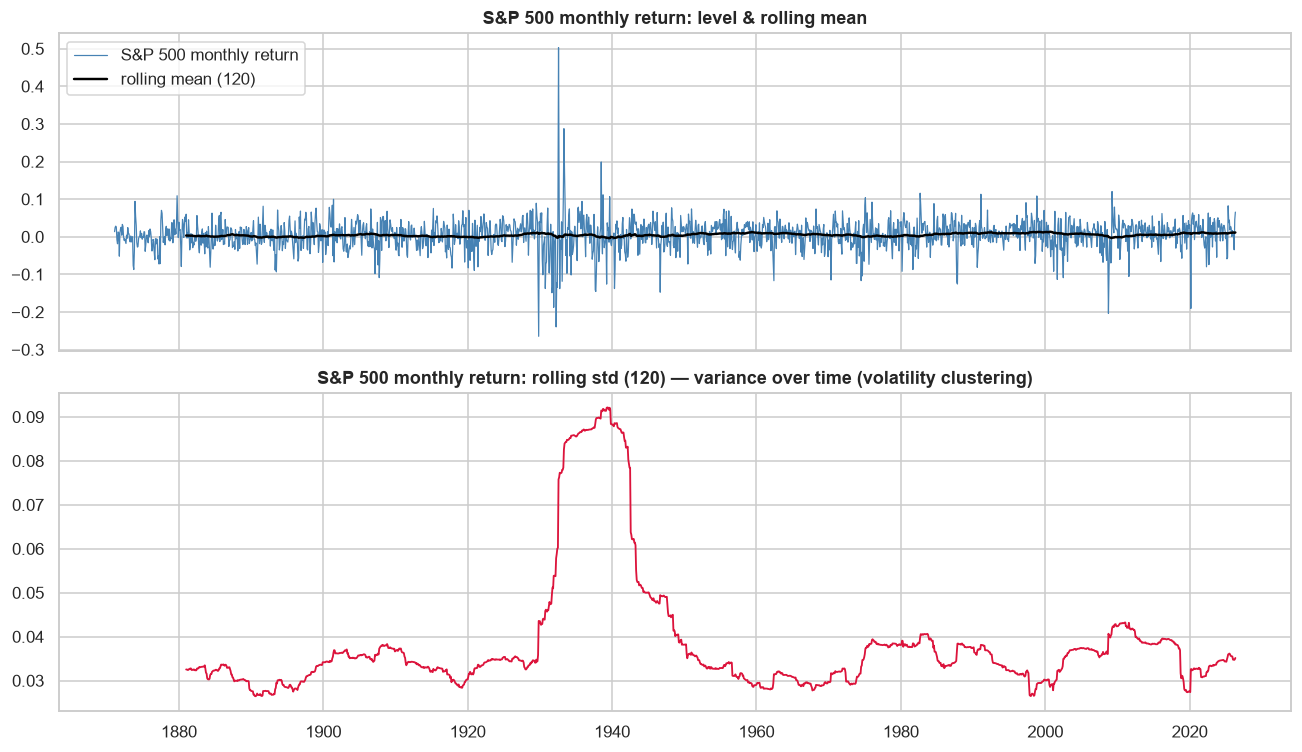

In [6]:
fig = ts.rolling_plot(ret, window=120, name="S&P 500 monthly return", fname="p2_rolling_return.png")
plt.show()

### 3. The components: trend, seasonality, cycle, noise

A time series is modelled as a combination of unobserved parts:

- **Trend (T)** — long-run direction (the upward drift of prices).
- **Seasonality (S)** — a *fixed-period* pattern (calendar: month-of-year, day-of-week).
- **Cycle (C)** — longer swings with *no fixed period* (business cycles, bull/bear regimes). Often folded into the trend.
- **Residual (R)** — what's left; ideally white noise.

Two ways they combine:

| model | form | use when | seasonal amplitude… |
|---|---|---|---|
| **Additive** | `y = T + S + R` | fluctuations are roughly constant in absolute size | …stays the same as the level rises |
| **Multiplicative** | `y = T × S × R` | fluctuations grow with the level | …grows with the level |

Key identity: **`log(T × S × R) = log T + log S + log R`** — logging turns a multiplicative
series into an additive one. That is *why* we log financial data before decomposing.

### 4. Decomposition in practice — classical vs STL

**Classical** (`seasonal_decompose`): estimates the trend with a centered moving average, then
averages the detrended values within each season. Simple, but the seasonal shape is forced to be
*identical every year* and the moving average loses points at both ends.

**STL** (Seasonal-Trend decomposition using Loess): fits trend and season with local regression.
It allows the seasonal pattern to **evolve**, is **robust** to outliers, and handles any period.
Prefer STL in practice.

First, CO₂ — where seasonality is unmistakable (plants breathe in a yearly cycle):

C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


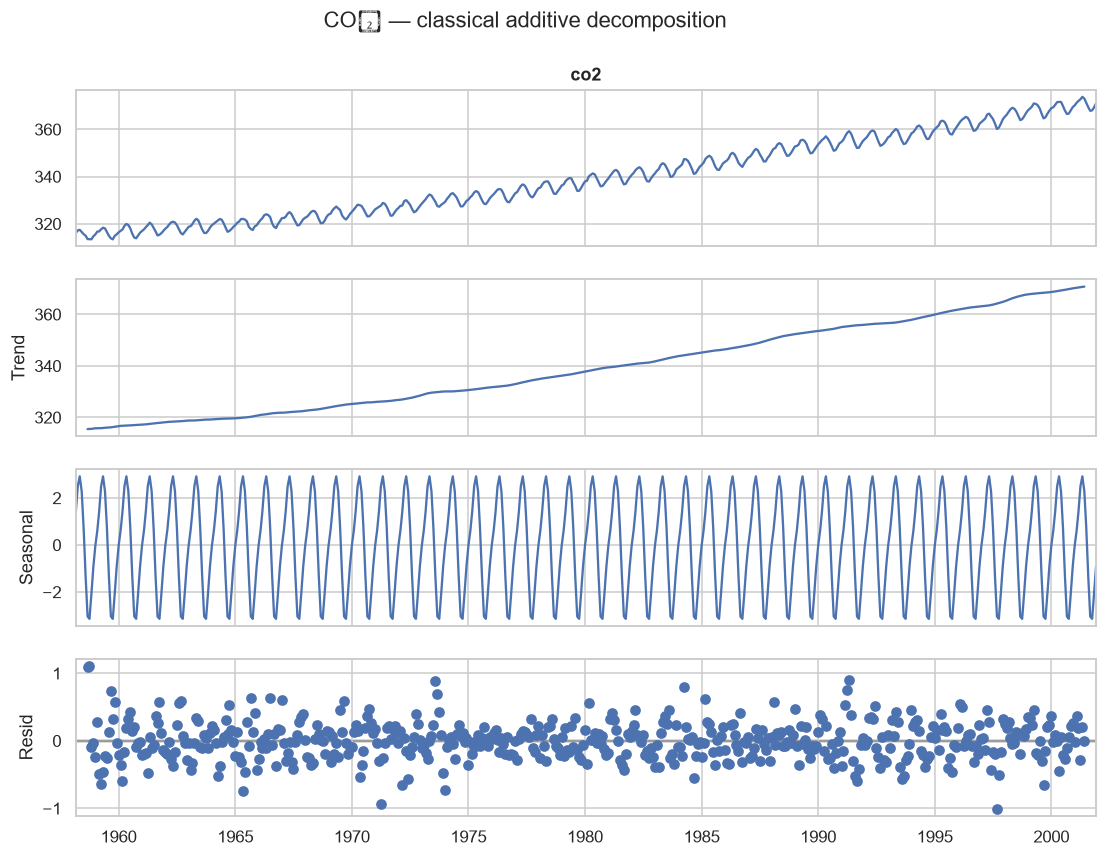

Seasonal swing: 6.07 ppm peak-to-trough, repeating every 12 months.


In [7]:
dec = seasonal_decompose(co2m, model="additive", period=12)
fig = dec.plot(); fig.set_size_inches(11, 8); fig.suptitle("CO₂ — classical additive decomposition", y=1.01)
eda.savefig(fig, "p2_co2_classical.png"); plt.show()
print("Seasonal swing: %.2f ppm peak-to-trough, repeating every 12 months." % (dec.seasonal.max()-dec.seasonal.min()))

C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


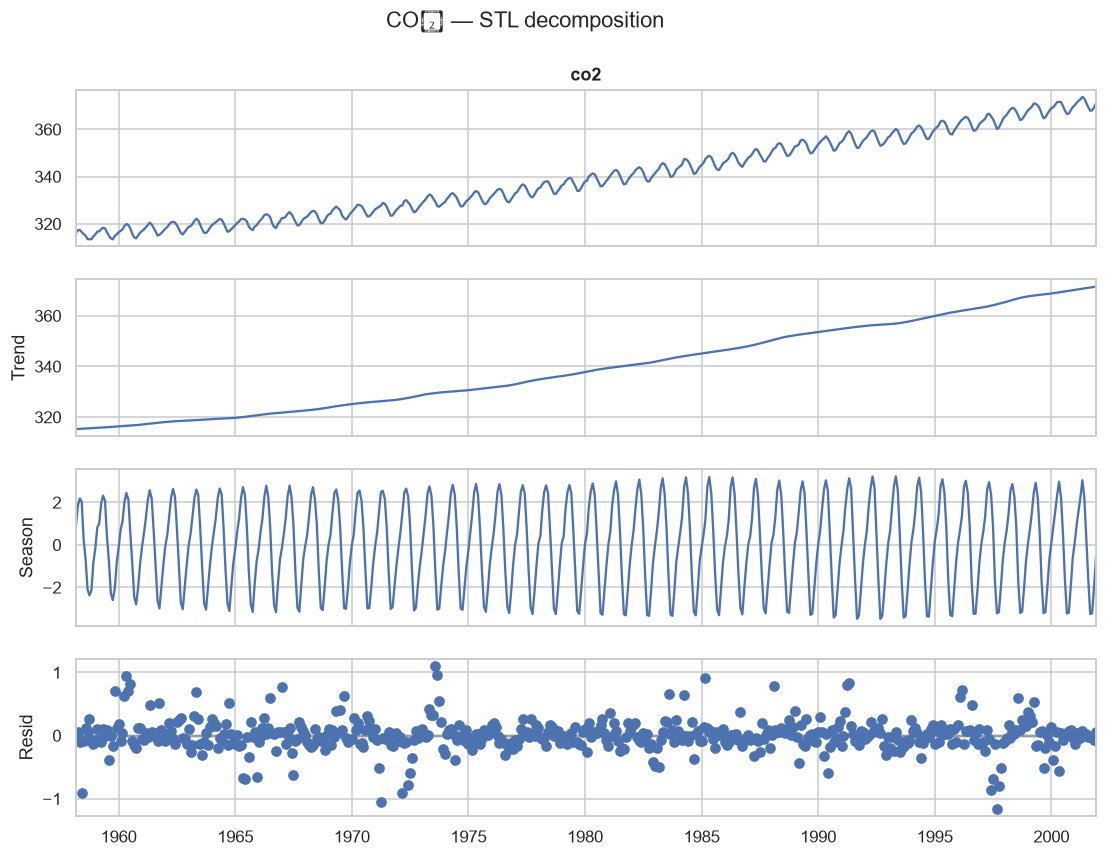

STL residual std = 0.255 ppm — the trend+seasonal capture almost everything.
CO₂ strengths: {'trend_strength': 1.0, 'seasonal_strength': 0.984} <- both trend and seasonality are strong


In [8]:
stl = STL(co2m, period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 8); fig.suptitle("CO₂ — STL decomposition", y=1.01)
eda.savefig(fig, "p2_co2_stl.png"); plt.show()
print("STL residual std = %.3f ppm — the trend+seasonal capture almost everything." % stl.resid.std())
print("CO₂ strengths:", ts.decomposition_strengths(stl), "<- both trend and seasonality are strong")

Now the same STL on **log(S&P 500)**. Watch the scale of the seasonal panel relative to the
trend — for an equity index it is tiny. That is the honest finding: **stocks trend strongly but
have essentially no calendar seasonality** (broadly consistent with market efficiency).

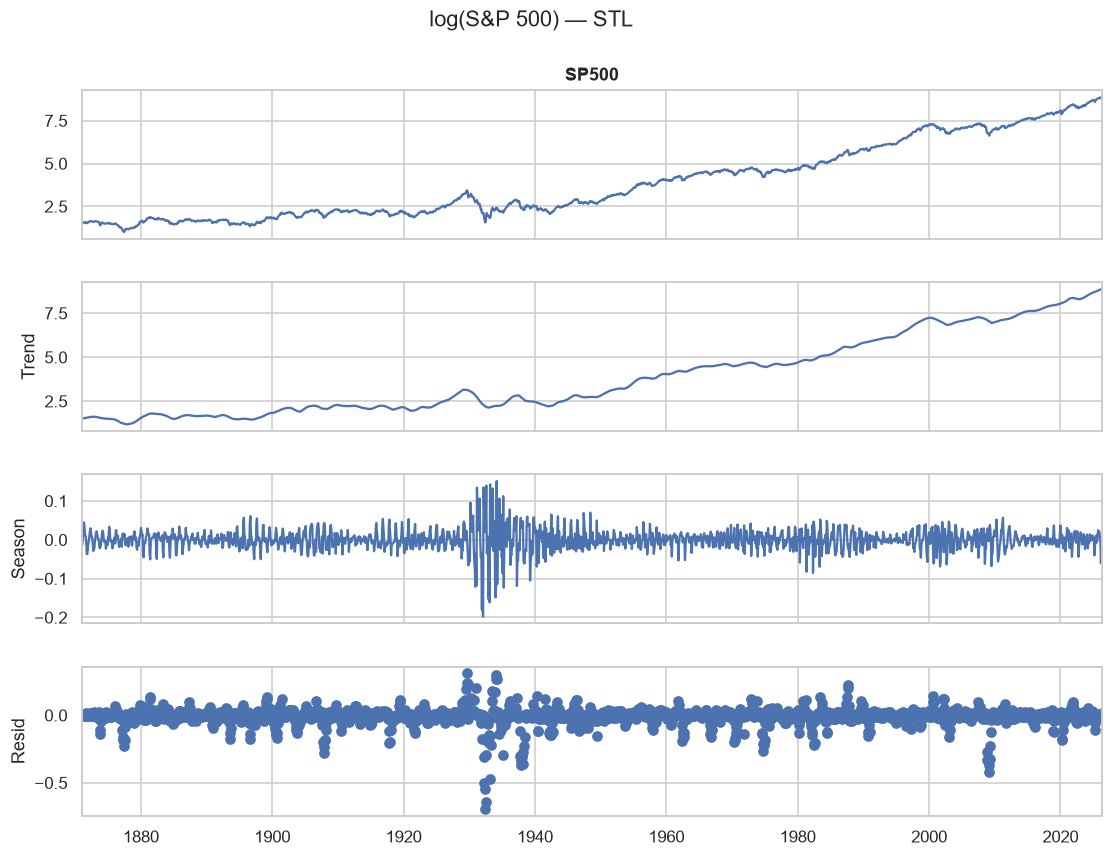

S&P 500 strengths: {'trend_strength': 0.999, 'seasonal_strength': 0.0}
CO₂     strengths: {'trend_strength': 1.0, 'seasonal_strength': 0.984}

Trend is near-total for both. But seasonal strength is 0.98 for CO₂ vs only 0.00 for the S&P 500 -> equities have ~no calendar seasonality.


In [9]:
stl_sp = STL(logp, period=12, robust=True).fit()
fig = stl_sp.plot(); fig.set_size_inches(11, 8); fig.suptitle("log(S&P 500) — STL", y=1.01)
eda.savefig(fig, "p2_sp500_stl.png"); plt.show()
sp_str, co2_str = ts.decomposition_strengths(stl_sp), ts.decomposition_strengths(stl)
print("S&P 500 strengths:", sp_str)
print("CO₂     strengths:", co2_str)
print(f"\nTrend is near-total for both. But seasonal strength is {co2_str['seasonal_strength']:.2f} for CO₂"
      f" vs only {sp_str['seasonal_strength']:.2f} for the S&P 500 -> equities have ~no calendar seasonality.")

We can still *look* for a calendar effect directly: average return by month-of-year. The
famous 'Sell in May' / Santa-rally stories live here — and you can see how small and noisy they
are compared to the month-to-month volatility.

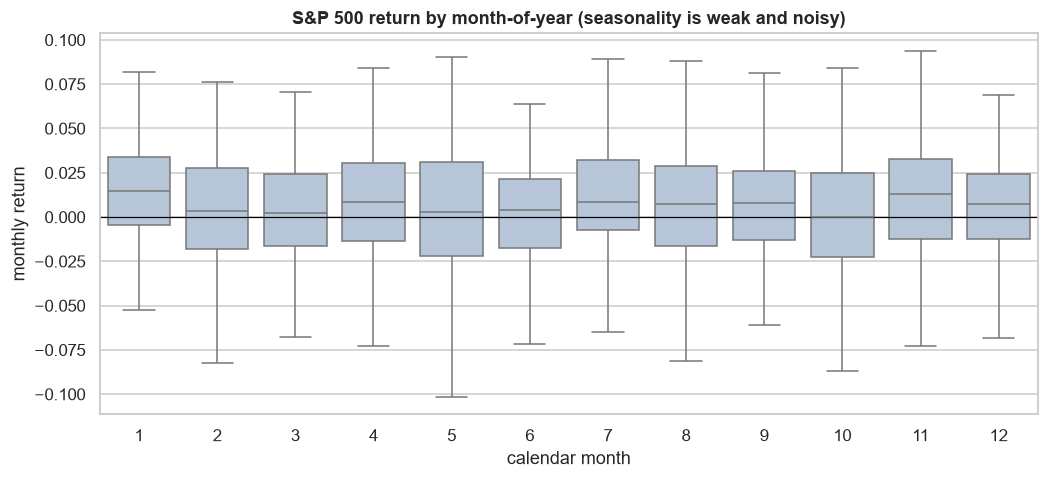

Date            1     2     3     4     5     6     7     8     9     10    11    12
avg % return  1.49  0.39  0.11  0.68  0.21  0.14  0.91  0.88  0.24 -0.34  0.67  0.39


In [10]:
by_month = ret.groupby(ret.index.month)
fig, ax = plt.subplots(figsize=(11, 4.5))
import seaborn as sns
sns.boxplot(x=ret.index.month, y=ret.values, ax=ax, color="lightsteelblue", showfliers=False)
ax.axhline(0, color="black", lw=0.8); ax.set_xlabel("calendar month"); ax.set_ylabel("monthly return")
ax.set_title("S&P 500 return by month-of-year (seasonality is weak and noisy)")
eda.savefig(fig, "p2_month_effect.png"); plt.show()
print((by_month.mean()*100).round(2).rename("avg % return").to_frame().T.to_string())

### 5. Stationarity — the property models demand

A series is **(weakly / covariance) stationary** if its statistical character does not change
over time:

1. **constant mean** (no trend),
2. **constant variance** (no growing/shrinking spread),
3. **autocovariance that depends only on the lag**, not on *when* you look.

Why it matters: ARIMA, VAR and most classical models *assume* stationarity, and regressing one
trending series on another invites **spurious correlation** (two unrelated random walks look
0.9-correlated). The standard move: transform the data until it is stationary, model that, then
invert.

Two tests with **opposite null hypotheses** — using them together resolves ambiguity:

- **ADF** — H₀: *unit root (non-stationary)*. Small p → **reject** → stationary.
- **KPSS** — H₀: *stationary*. Small p → **reject** → non-stationary.

| ADF says | KPSS says | verdict | action |
|---|---|---|---|
| stationary | stationary | **stationary** | model as-is |
| non-stat. | non-stat. | **unit root** | **difference** |
| stationary | non-stat. | **difference-stationary** | difference |
| non-stat. | stationary | **trend-stationary** | **detrend** (remove a fitted trend) |

In [11]:
for label, s in [("S&P 500 price", price), ("log(price)", logp), ("monthly return", ret)]:
    table, verdict = ts.stationarity_report(s, name=label)
    print(f"\n=== {label} ===")
    print(table.to_string())
    print("VERDICT:", verdict)


=== S&P 500 price ===
        stat  p_value  crit_5%  stationary_5pct
test                                           
ADF   9.2191     1.00  -2.8631            False
KPSS  3.0115     0.01   0.4630            False
VERDICT: NON-STATIONARY (unit root) -> difference



=== log(price) ===
        stat  p_value  crit_5%  stationary_5pct
test                                           
ADF   1.7630   0.9983  -2.8631            False
KPSS  6.2997   0.0100   0.4630            False
VERDICT: NON-STATIONARY (unit root) -> difference

=== monthly return ===
         stat  p_value  crit_5%  stationary_5pct
test                                            
ADF  -10.6758   0.0000  -2.8631             True
KPSS   0.4314   0.0636   0.4630             True
VERDICT: STATIONARY


The canonical result, confirmed on real data: the **price is non-stationary** (both tests
agree — a unit root / random walk with drift), while its **returns are stationary**. This is the
reason quant finance models *returns*, not *prices*. Differencing the log price once gives the
log return — i.e. the price is **I(1)** (integrated of order 1).

### 6. Autocorrelation — ACF & PACF, and how to read order

- **ACF(k)** = correlation between `yₜ` and `yₜ₋ₖ`. It includes *indirect* paths (if today depends
  on yesterday and yesterday on the day before, the ACF at lag 2 picks up that chain).
- **PACF(k)** = the *direct* correlation at lag k, with the intermediate lags partialled out.

The classic identification table (the basis of Box–Jenkins, Part 3):

| pattern | ACF | PACF |
|---|---|---|
| **AR(p)** | tails off (decays) | **cuts off after lag p** |
| **MA(q)** | **cuts off after lag q** | tails off |
| **ARMA(p,q)** | tails off | tails off |

Anything inside the shaded band is statistically indistinguishable from zero.

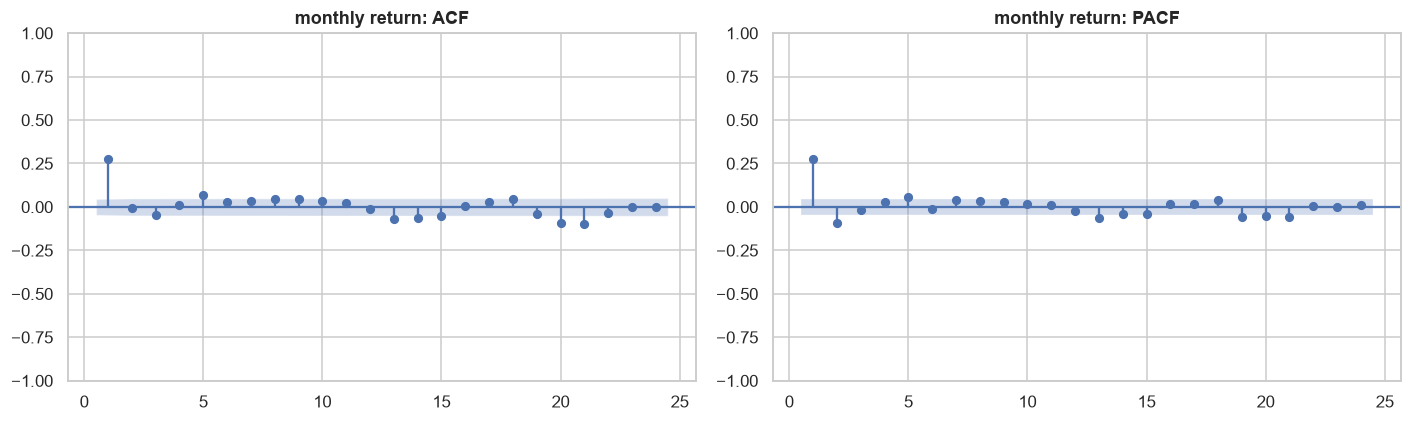

In [12]:
fig = ts.acf_pacf_plot(ret, lags=24, name="monthly return", fname="p2_acf_pacf_return.png")
plt.show()

Returns are *close to* white noise but not quite — there's a real spike at lag 1. A formal
**Ljung-Box** test (H₀: no autocorrelation) confirms it:

In [13]:
print(ts.ljung_box(ret, lags=12).loc[[1, 6, 12]].to_string())
print("\nlb_pvalue ~ 0 -> returns carry SOME linear structure.")

     lb_stat  lb_pvalue
1   139.9943        0.0
6   154.4399        0.0
12  167.2982        0.0

lb_pvalue ~ 0 -> returns carry SOME linear structure.


**Important caveat — data construction, not free money.** Shiller's monthly price is a
*within-month average of daily closes*, not the month-end close. Averaging mechanically induces
positive autocorrelation in the resulting returns (the Working effect). So a chunk of that lag-1
spike is an artifact of how the series is built, not a tradeable signal. Always ask how a series
was *constructed* before trading its autocorrelation — exactly the Part-1 habit, applied to time.

### 7. Volatility clustering — the variance has memory (ARCH)

Returns themselves are nearly unpredictable, but their **magnitude** is highly predictable: big
moves follow big moves. We see it by running the ACF on **squared** (or absolute) returns — a
proxy for variance. Strong, slowly-decaying autocorrelation there = **volatility clustering**,
the empirical fact that motivates **ARCH/GARCH** models (a stretch topic for later).

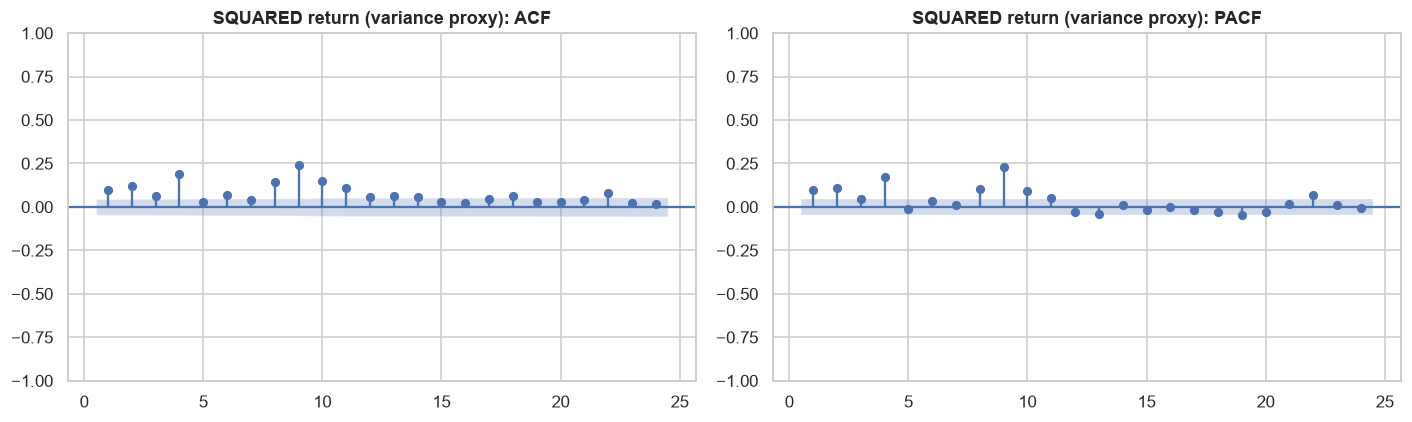

Ljung-Box on squared returns:
     lb_stat  lb_pvalue
1    16.9704        0.0
6   130.2667        0.0
12  352.6292        0.0


In [14]:
fig = ts.acf_pacf_plot(ret**2, lags=24, name="SQUARED return (variance proxy)", fname="p2_acf_squared.png")
plt.show()
print("Ljung-Box on squared returns:")
print(ts.ljung_box(ret**2, lags=12).loc[[1, 6, 12]].to_string())

Contrast the two: **raw** returns lose autocorrelation almost immediately, but **squared**
returns stay autocorrelated for many lags and the Ljung-Box statistic *grows*. The level is
unpredictable; the **risk** is persistent. This is the time-series face of Part 1's fat tails —
the extremes cluster instead of arriving independently.

### 8. Differencing — turning non-stationary into stationary

**Differencing** replaces the level with its change: `Δyₜ = yₜ − yₜ₋₁`. It removes a trend (a
linear trend dies after one difference). The number of differences needed is the **order of
integration d**; here `Δ log(price) = log return`, so price is **I(1)**.

- **Seasonal differencing** `yₜ − yₜ₋ₘ` (m = period) removes a seasonal pattern — used for CO₂.
- **Over-differencing** is a real hazard: differencing a series that's already stationary
  *inflates the variance* and stamps a tell-tale **strong negative lag-1 autocorrelation** into
  the ACF. More differencing is not safer.

In [15]:
# Price is I(1): one log-difference makes it stationary.
diff1 = logp.diff().dropna()
_, v_price = ts.stationarity_report(logp,  name="log price")
_, v_diff  = ts.stationarity_report(diff1, name="Δ log price")
print("log price    ->", v_price)
print("Δ log price  ->", v_diff, " (== monthly log return)")

log price    -> NON-STATIONARY (unit root) -> difference
Δ log price  -> STATIONARY  (== monthly log return)


In [16]:
# Over-differencing demo: difference the ALREADY-stationary returns again.
over = ret.diff().dropna()
from statsmodels.tsa.stattools import acf
print("variance  ret = %.5f   |  Δret (over-differenced) = %.5f  <- inflated" % (ret.var(), over.var()))
print("lag-1 ACF ret = %+.3f   |  Δret = %+.3f  <- strong negative spike = over-differenced" % (acf(ret, nlags=1)[1], acf(over, nlags=1)[1]))

variance  ret = 0.00164   |  Δret (over-differenced) = 0.00238  <- inflated
lag-1 ACF ret = +0.274   |  Δret = -0.305  <- strong negative spike = over-differenced


In [17]:
# Seasonal differencing removes the CO2 cycle.
co2_sd = co2m.diff(12).dropna()
_, v_co2  = ts.stationarity_report(co2m,   name="CO₂ level")
_, v_co2d = ts.stationarity_report(co2_sd, name="CO₂ seasonally differenced")
print("CO₂ level                  ->", v_co2)
print("CO₂ minus 12-months-ago    ->", v_co2d)

CO₂ level                  -> NON-STATIONARY (unit root) -> difference
CO₂ minus 12-months-ago    -> DIFFERENCE-STATIONARY -> difference


### Takeaways

- **Index hygiene first**: typed, sorted, gapless, with a declared frequency. Returns *compound*, not add.
- **Look before testing**: rolling mean reveals trend; rolling std reveals volatility clustering.
- **Additive vs multiplicative**, and the log trick that converts one to the other; **STL** is the
  decomposition workhorse (evolving seasonality, robust). The S&P 500 has trend but ~no seasonality.
- **Stationarity** is what models demand. **ADF × KPSS** (opposite nulls) → a 2×2 decision table.
  Price is **I(1)**; returns are stationary → *model returns, not prices*.
- **ACF/PACF** identify model order (AR cuts in PACF, MA cuts in ACF); **Ljung-Box** tests white noise.
  Mind how a series was *constructed* (Shiller's monthly averaging fakes lag-1 autocorrelation).
- **Squared returns** stay autocorrelated → volatility clustering / ARCH; the variance is predictable
  even when the level isn't.
- **Difference** to reach stationarity — but watch for **over-differencing** (variance blows up,
  lag-1 ACF turns sharply negative).

**Next — Part 3 (Univariate Forecasting):** baselines → ETS (Holt-Winters) → ARIMA/SARIMA, using
exactly these tools (stationarity to set `d`, ACF/PACF to set `p,q`) plus Box–Jenkins diagnostics
and `auto_arima`. We'll install the forecasting extras (pmdarima) at that point.